In [24]:
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [25]:
shapefile_path = r"C:\Users\naman\Desktop\INTERNSHIP\INDIA SPACE ACADMEY\MINI Project\Madhya pradesh shp file temp + NDVI"

ndvi_path = r"C:\Users\naman\Desktop\INTERNSHIP\INDIA SPACE ACADMEY\MINI Project\MP_NDVI_Mar_May_2024(4).tif"

temperature_path = r"C:\Users\naman\Desktop\INTERNSHIP\INDIA SPACE ACADMEY\MINI Project\MP_Temperature_Mar_May_2024(4).tif"

In [26]:
gdf = gpd.read_file(shapefile_path)

gdf.head()

,Shape_Leng,STATUS,ADM1_CODE,ADM0_NAME,ADM0_CODE,EXP1_YEAR,Shape_Area,DISP_AREA,STR1_YEAR,ADM1_NAME,geometry
0,62.373589,Member State,70079,India,115,3000,27.246919,NO,2001,Madhya Pradesh,"POLYGON ((74.03467 22.50837, 74.03893 22.514, ..."


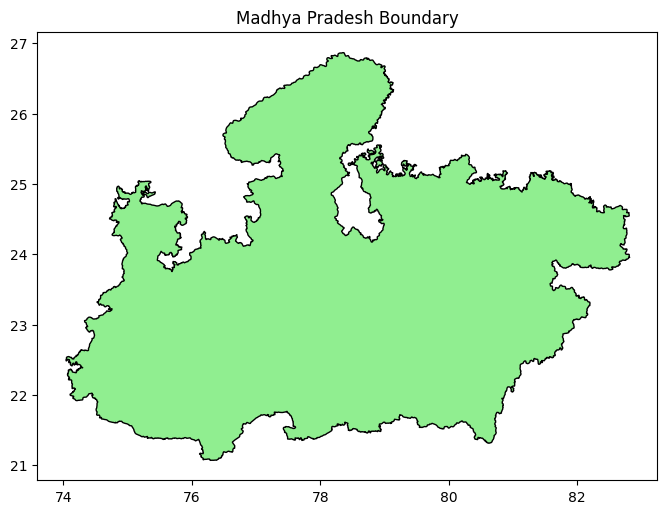

In [47]:
gdf.plot(
    figsize=(8, 8),
    color="lightgreen",
    edgecolor="black"
)

plt.title("Madhya Pradesh Boundary")

plt.show()

In [28]:
ndvi = rasterio.open(ndvi_path)

print(ndvi)

<open DatasetReader name='C:\Users\naman\Desktop\INTERNSHIP\INDIA SPACE ACADMEY\MINI Project\MP_NDVI_Mar_May_2024(4).tif' mode='r'>


In [29]:
ndvi_data = ndvi.read(1)

print(ndvi_data)

[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


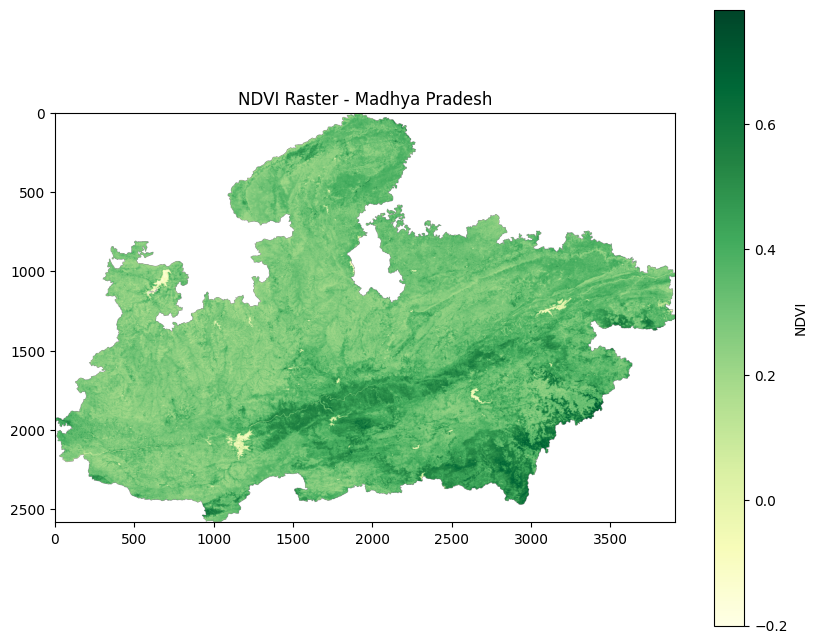

In [30]:
plt.figure(figsize=(10,8))

plt.imshow(ndvi_data, cmap="YlGn")

plt.colorbar(label="NDVI")

plt.title("NDVI Raster - Madhya Pradesh")

plt.show()

In [31]:
temperature = rasterio.open(temperature_path)

print(temperature)

<open DatasetReader name='C:\Users\naman\Desktop\INTERNSHIP\INDIA SPACE ACADMEY\MINI Project\MP_Temperature_Mar_May_2024(4).tif' mode='r'>


In [32]:
temperature_data = temperature.read(1)

print(temperature_data)

[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


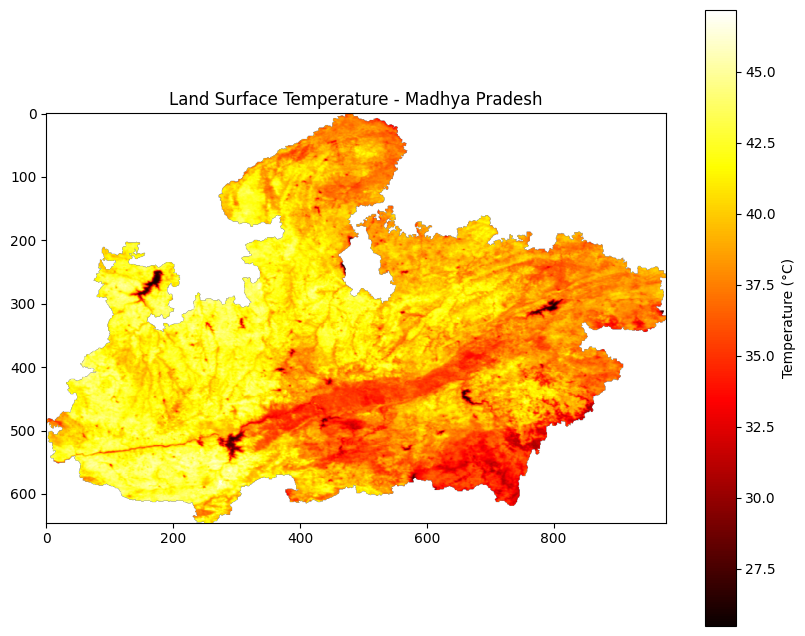

In [33]:
plt.figure(figsize=(10,8))

plt.imshow(temperature_data, cmap="hot")

plt.colorbar(label="Temperature (°C)")

plt.title("Land Surface Temperature - Madhya Pradesh")

plt.show()

In [34]:
mean_ndvi = np.nanmean(ndvi_data)

print("Mean NDVI Value:", mean_ndvi)

Mean NDVI Value: 0.33010748839874887


In [35]:
mean_temperature = np.nanmean(temperature_data)

print("Mean Temperature:", mean_temperature)

Mean Temperature: 39.46107403744251


In [36]:
summary_table = pd.DataFrame({
    "Variable": ["Mean NDVI", "Mean Temperature"],
    "Value": [mean_ndvi, mean_temperature]
})

summary_table

,Variable,Value
0,Mean NDVI,0.330107
1,Mean Temperature,39.461074


In [37]:
summary_table.to_csv(
    "Wildfire_Summary_Table.csv",
    index=False
)

print("Summary table exported successfully")

Summary table exported successfully


In [38]:
susceptibility = np.where(
    (ndvi_data < 0.3) & (temperature_data > 40),
    2,
    np.where(
        (ndvi_data < 0.4) & (temperature_data > 35),
        1,
        0
    )
)

ValueError: operands could not be broadcast together with shapes (2583,3907) (646,978) 

In [ ]:
from rasterio.warp import reproject, Resampling

temperature_resampled = np.empty(
    ndvi_data.shape,
    dtype=np.float32
)

reproject(
    source=temperature_data,
    destination=temperature_resampled,
    src_transform=temperature.transform,
    src_crs=temperature.crs,
    dst_transform=ndvi.transform,
    dst_crs=ndvi.crs,
    resampling=Resampling.bilinear
)

print("NDVI shape:", ndvi_data.shape)
print("Original Temperature shape:", temperature_data.shape)
print("Resampled Temperature shape:", temperature_resampled.shape)

NDVI shape: (2583, 3907)
Original Temperature shape: (646, 978)
Resampled Temperature shape: (2583, 3907)


In [ ]:
susceptibility = np.where(
    (ndvi_data < 0.3) & (temperature_resampled > 40),
    2,
    np.where(
        (ndvi_data < 0.4) & (temperature_resampled > 35),
        1,
        0
    )
)

print("Susceptibility map created successfully")
print(np.unique(susceptibility))


Susceptibility map created successfully
[0 1 2]


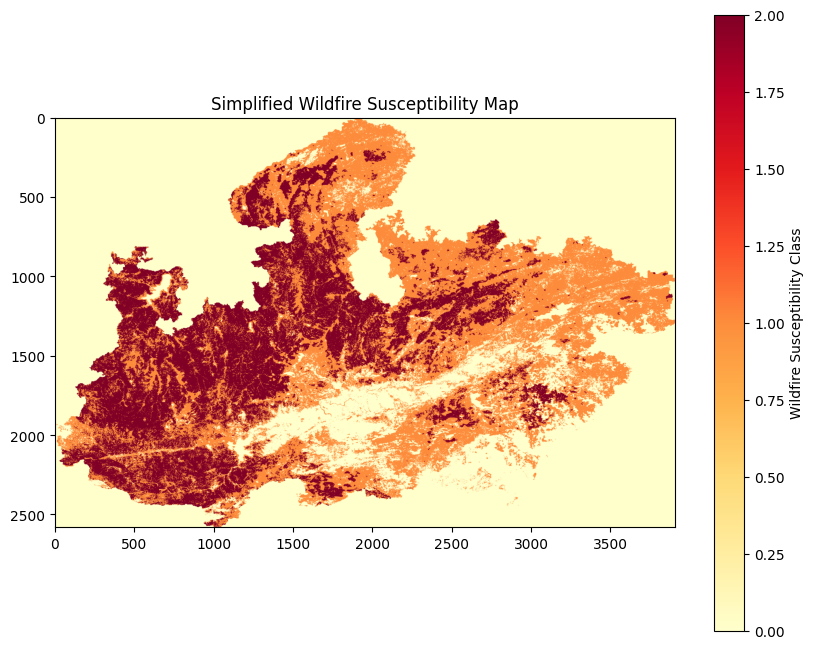

In [ ]:
plt.figure(figsize=(10,8))

plt.imshow(
    susceptibility,
    cmap="YlOrRd"
)

plt.colorbar(label="Wildfire Susceptibility Class")

plt.title("Simplified Wildfire Susceptibility Map")

plt.show()

In [ ]:
X = np.column_stack((
    ndvi_data.flatten(),
    temperature_resampled.flatten()
))

y = susceptibility.flatten()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (10091781, 2)
Target shape: (10091781,)


In [ ]:
valid_mask = (
    ~np.isnan(X[:,0]) &
    ~np.isnan(X[:,1]) &
    ~np.isnan(y)
)

X_valid = X[valid_mask]
y_valid = y[valid_mask]

print("Clean feature shape:", X_valid.shape)
print("Clean target shape:", y_valid.shape)

Clean feature shape: (5394180, 2)
Clean target shape: (5394180,)


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_valid,
    y_valid,
    test_size=0.3,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (3775926, 2)
Testing samples: (1618254, 2)


In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully")

Random Forest model trained successfully


In [41]:
rf_prediction = rf_model.predict(X_test)

print("Random Forest prediction completed")

Random Forest prediction completed


In [42]:
from sklearn.metrics import accuracy_score, classification_report

rf_accuracy = accuracy_score(y_test, rf_prediction)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, rf_prediction))

Random Forest Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    319625
           1       1.00      1.00      1.00    773023
           2       1.00      1.00      1.00    525606

    accuracy                           1.00   1618254
   macro avg       1.00      1.00      1.00   1618254
weighted avg       1.00      1.00      1.00   1618254



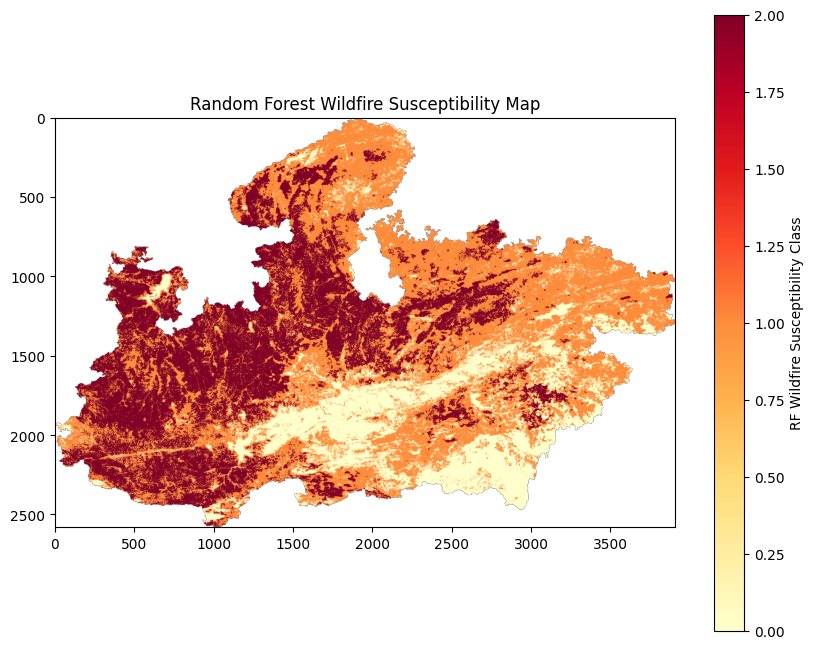

In [43]:
rf_full_prediction = rf_model.predict(X_valid)

rf_susceptibility_map = np.full(
    susceptibility.shape,
    np.nan
)

rf_susceptibility_map[valid_mask.reshape(susceptibility.shape)] = rf_full_prediction

plt.figure(figsize=(10,8))

plt.imshow(
    rf_susceptibility_map,
    cmap="YlOrRd"
)

plt.colorbar(label="RF Wildfire Susceptibility Class")

plt.title("Random Forest Wildfire Susceptibility Map")

plt.show()


In [44]:
importance = rf_model.feature_importances_

feature_table = pd.DataFrame({
    "Feature": ["NDVI", "Temperature"],
    "Importance": importance
})

feature_table

,Feature,Importance
0,NDVI,0.647771
1,Temperature,0.352229


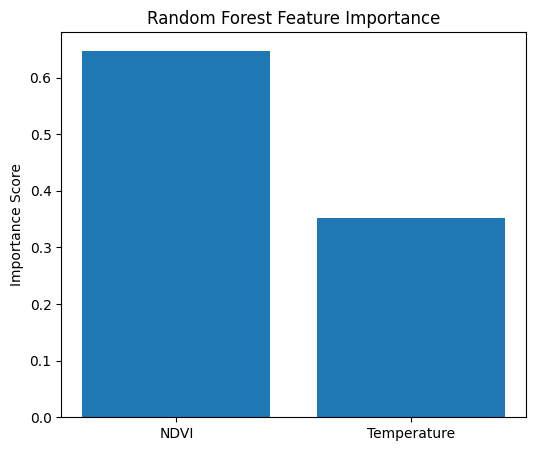

In [45]:
plt.figure(figsize=(6,5))

plt.bar(
    feature_table["Feature"],
    feature_table["Importance"]
)

plt.title("Random Forest Feature Importance")

plt.ylabel("Importance Score")

plt.show()
